<a href="https://colab.research.google.com/github/sisodia91/data-analysis-tasks/blob/main/Task_3_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error



In [41]:
df = pd.read_csv('/content/airline-passengers.csv')

In [42]:
print("FIRST 5 ROWS")
print(df.head())


FIRST 5 ROWS
     month  total_passengers
0  1949-01               112
1  1949-02               118
2  1949-03               132
3  1949-04               129
4  1949-05               121


In [43]:
print("\nCOLUMN NAMES")
print(df.columns)


COLUMN NAMES
Index(['month', 'total_passengers'], dtype='object')


In [44]:
print("\nDATASET INFO")
print(df.info())



DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   month             144 non-null    object
 1   total_passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB
None


In [45]:
print("\nMISSING VALUES")
print(df.isnull().sum())



MISSING VALUES
month               0
total_passengers    0
dtype: int64


In [46]:
df['month'] = pd.to_datetime(df['month'])

In [47]:
df.set_index('month', inplace=True)

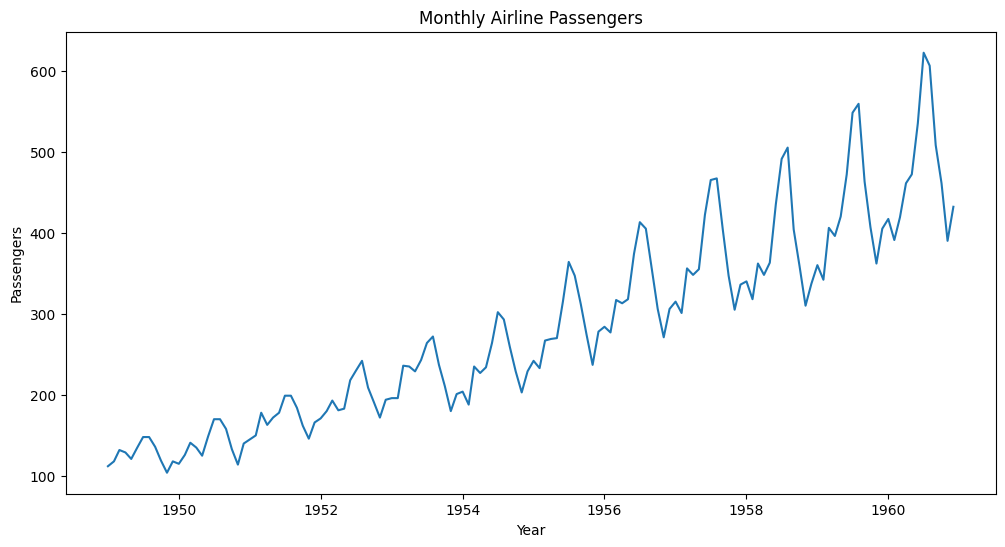

In [48]:
plt.figure(figsize=(12,6))

plt.plot(df.index,
         df['total_passengers'])

plt.title("Monthly Airline Passengers")
plt.xlabel("Year")
plt.ylabel("Passengers")

plt.show()



In [49]:
quarterly = df.resample('QE').mean()

print("\nQUARTERLY DATA")
print(quarterly.head())


QUARTERLY DATA
            total_passengers
month                       
1949-03-31        120.666667
1949-06-30        128.333333
1949-09-30        144.000000
1949-12-31        113.666667
1950-03-31        127.333333


In [50]:
decomposition = seasonal_decompose(
    df['total_passengers'],
    model='multiplicative',
    period=12
)


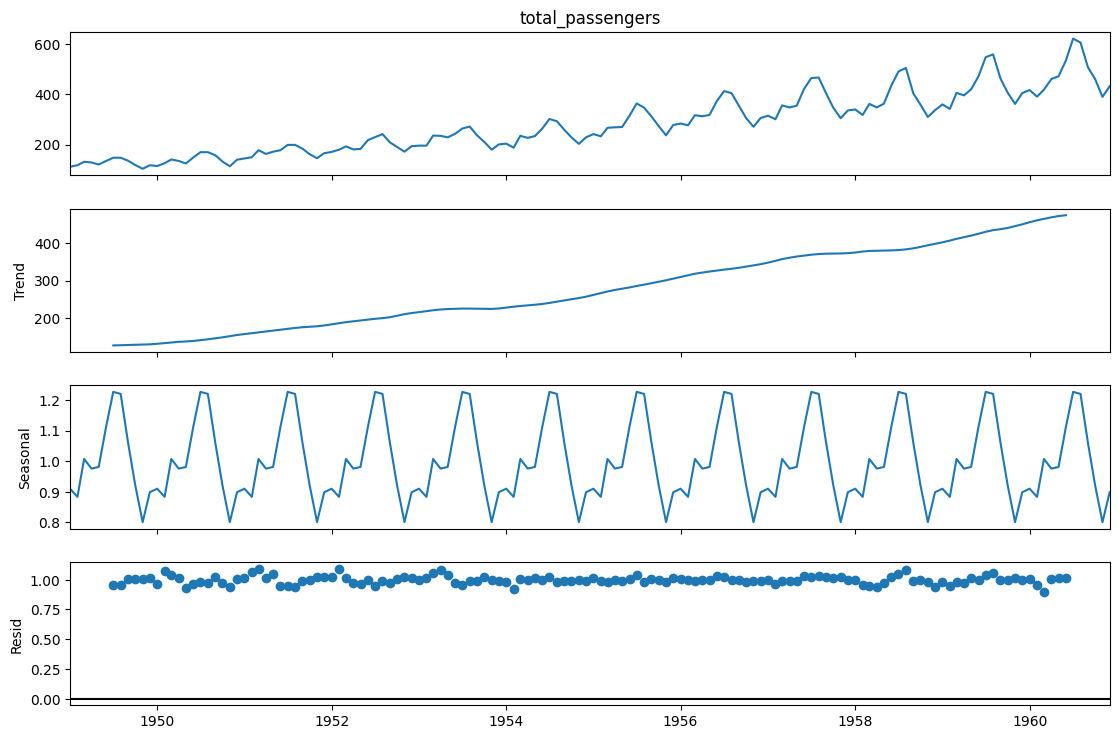

In [51]:
fig = decomposition.plot()

fig.set_size_inches(12,8)

plt.show()


In [52]:
df['MA_6'] = df['total_passengers'].rolling(window=6).mean()

df['MA_12'] = df['total_passengers'].rolling(window=12).mean()

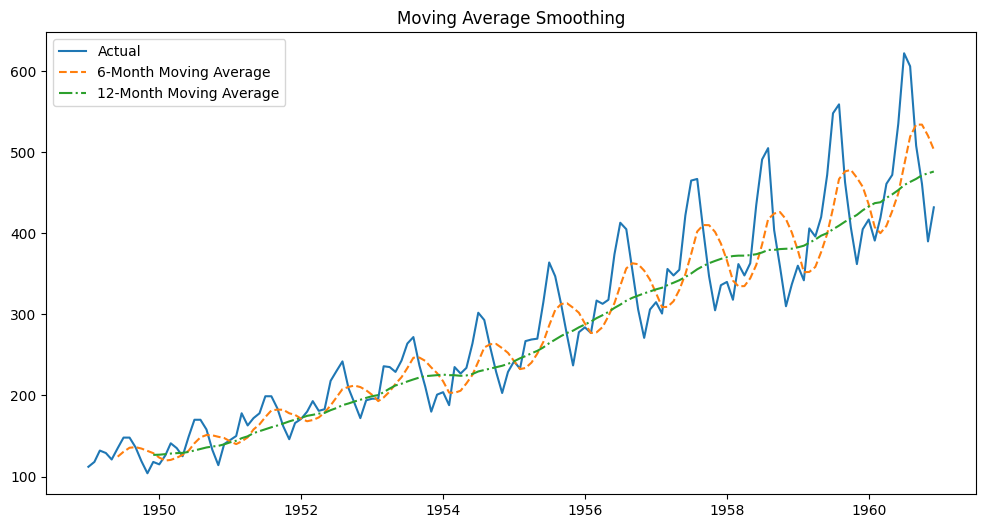

In [53]:

plt.figure(figsize=(12,6))

plt.plot(df['total_passengers'],
         label='Actual')

plt.plot(df['MA_6'],
         label='6-Month Moving Average',
         linestyle='--')

plt.plot(df['MA_12'],
         label='12-Month Moving Average',
         linestyle='-.')

plt.legend()

plt.title("Moving Average Smoothing")

plt.show()



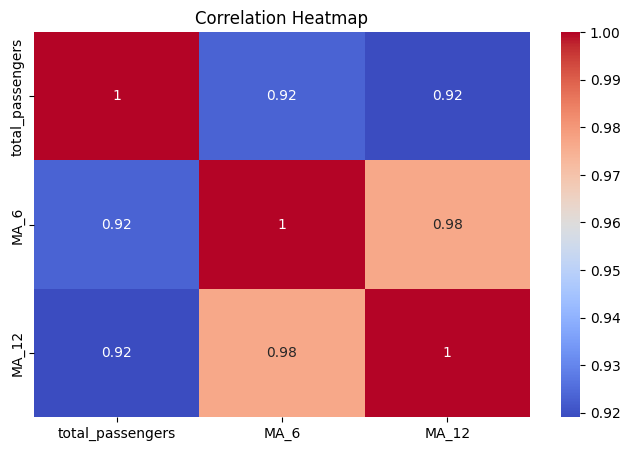

In [54]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [55]:
train = df.iloc[:-12]

test = df.iloc[-12:]



In [56]:
model = SARIMAX(
    train['total_passengers'],
    order=(2,1,1),
    seasonal_order=(1,1,1,12)

)

result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optim

In [57]:
forecast = result.forecast(steps=12)

In [58]:

rmse = np.sqrt(
    mean_squared_error(
        test['total_passengers'],
        forecast
    )
)

print("\nRMSE VALUE")
print(rmse)



RMSE VALUE
21.16996463074816


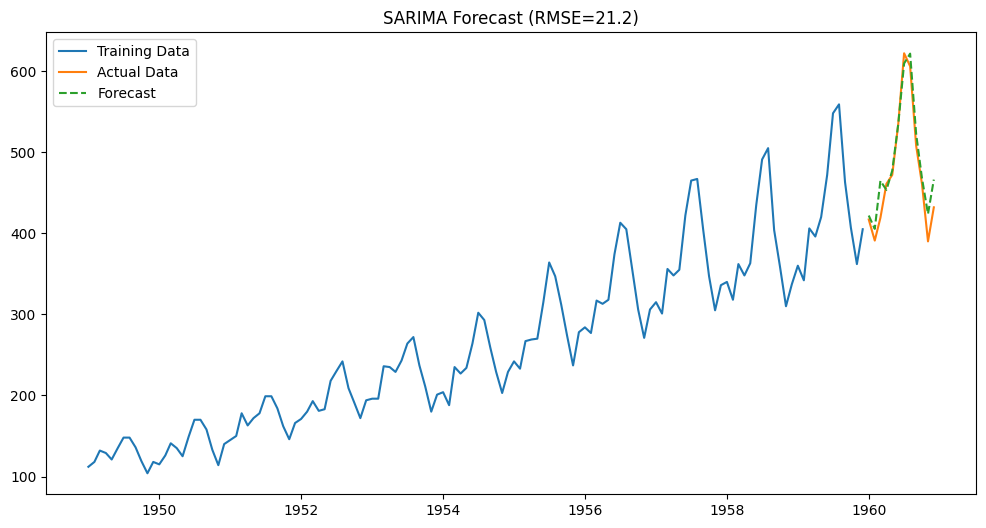

In [59]:
plt.figure(figsize=(12,6))

plt.plot(train.index,
         train['total_passengers'],
         label='Training Data')

plt.plot(test.index,
         test['total_passengers'],
         label='Actual Data')

plt.plot(test.index,
         forecast,
         label='Forecast',
         linestyle='--')

plt.legend()

plt.title(f"SARIMA Forecast (RMSE={rmse:.1f})")

plt.show()


In [60]:
forecast_df = pd.DataFrame({
    'Actual': test['total_passengers'],
    'Forecast': forecast
})

print("\nFORECAST RESULTS")
print(forecast_df)



FORECAST RESULTS
            Actual    Forecast
1960-01-01     417  421.877485
1960-02-01     391  405.424550
1960-03-01     419  464.696999
1960-04-01     461  453.476362
1960-05-01     472  477.274412
1960-06-01     535  534.835426
1960-07-01     622  609.460547
1960-08-01     606  621.592159
1960-09-01     508  522.623641
1960-10-01     461  467.952979
1960-11-01     390  423.800744
1960-12-01     432  466.182533


In [61]:
print("\nBUSINESS INSIGHTS")

print("""
1. Passenger traffic shows strong upward growth.

2. Airline demand follows yearly seasonality.

3. Peak travel months occur in mid-year.

4. SARIMA model successfully captured trend and seasonality.

5. Forecasting helps airlines optimize:
   - staffing
   - fuel planning
   - ticket pricing
   - flight scheduling
""")


BUSINESS INSIGHTS

1. Passenger traffic shows strong upward growth.

2. Airline demand follows yearly seasonality.

3. Peak travel months occur in mid-year.

4. SARIMA model successfully captured trend and seasonality.

5. Forecasting helps airlines optimize:
   - staffing
   - fuel planning
   - ticket pricing
   - flight scheduling

